# Econometrics

Two questions, two parts.

**Part A, hourly.** How does Swedish national wind generation affect the day-ahead
price, and does the effect differ across SE1 to SE4?

**Part B, monthly.** What explains the difference in price levels between SE1 and
SE4?

Both read `panel_hourly` and `panel_monthly` from PostgreSQL and write nothing back.
Regression tables go to `tables/` as CSV, diagnostic plots to `figures/`.

Wind, solar, load and residual load are converted from MW to **GW** so that every
coefficient reads as EUR/MWh per additional GW. Nothing else is rescaled.

File paths below are relative to the repository root. Run from the project root or `notebooks/`.

In [1]:
from pathlib import Path

# Resolve paths from the repository root when launched here or from notebooks/.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'data' / 'raw').is_dir() and (path / 'notebooks').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run this notebook from the project root or notebooks/ folder.')

import os
import subprocess
import sys
import warnings

for package in ['linearmodels', 'arch']:
    try:
        __import__(package)
    except ImportError:
        print(f'installing {package}')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', package], check=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
from sqlalchemy import create_engine

import linearmodels
print('pandas', pd.__version__, '| statsmodels', sm.__version__, '| linearmodels', linearmodels.__version__)

pandas 3.0.3 | statsmodels 0.14.6 | linearmodels 7.0


In [2]:
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')

FIG_DIR = PROJECT_ROOT / 'figures'
TAB_DIR = PROJECT_ROOT / 'tables'
LI_DIR = os.path.join(FIG_DIR, 'linkedin')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
os.makedirs(LI_DIR, exist_ok=True)

ZONES = ['SE1', 'SE2', 'SE3', 'SE4']
# Two blues for the northern zones, two oranges for the southern pair, so the
# north/south split the analysis turns on is legible before the legend is read.
ZONE_COLOUR = {'SE1': '#378ADD', 'SE2': '#85B7EB', 'SE3': '#D85A30', 'SE4': '#F0997B'}

# 1080 x 1350 at 200 dpi: the portrait size used for the shareable copies.
LI_FIGSIZE = (1080 / 200, 1350 / 200)

plt.rcParams.update({
    'savefig.dpi': 200,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.titlepad': 12,
    'text.color': '#1A1A1A',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
})


def tidy_axes(ax, grid='y'):
    """Shared look: no top or right spine, one faint grid direction."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('#B0B0B0')
        ax.spines[side].set_linewidth(1.0)
    ax.grid(False)
    if grid:
        ax.grid(True, axis=grid, color='#DDDDDD', linewidth=0.7)
        ax.set_axisbelow(True)
    return ax


def save_linkedin(fig, name):
    """Write an exact 1080 x 1350 copy to figures/linkedin/<name>.png.

    bbox_inches is deliberately left off here: it retrims the canvas and would
    break the pixel dimensions.
    """
    path = os.path.join(LI_DIR, name + '.png')
    fig.savefig(path, dpi=200)
    print('saved', path)
    return path


def save_table(frame, name):
    path = os.path.join(TAB_DIR, name + '.csv')
    frame.to_csv(path)
    print('saved', path)
    return path


def save_fig(fig, name, dpi=200):
    path = os.path.join(FIG_DIR, name + '.png')
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print('saved', path)
    return path

In [3]:
# Credentials are read from the repository-root .env, which is gitignored. Copy .env.example to .env
# and set PG_URL there.
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / '.env')
ENGINE_URL = os.environ["PG_URL"]
engine = create_engine(ENGINE_URL)

# Read-only.
hourly = pd.read_sql('select * from panel_hourly order by ts_utc, zone', engine)
monthly = pd.read_sql('select * from panel_monthly order by zone, year, month', engine)
print('loaded', hourly.shape, monthly.shape)

loaded (171478, 29) (240, 37)


In [4]:
# psycopg2 hands back timestamptz with the session offset attached, which can leave
# the column as object dtype; force it so every .dt and resample call works.
hourly['ts_utc'] = pd.to_datetime(hourly['ts_utc'], utc=True)
hourly['ts_local'] = pd.to_datetime(hourly['ts_local'])

# MW to GW, so coefficients read as EUR/MWh per GW.
for col in ['wind_onshore_mw', 'solar_mw', 'load_mw', 'residual_load_mw']:
    hourly[col.replace('_mw', '_gw')] = hourly[col] / 1000.0

hourly['date_local'] = hourly['ts_local'].dt.date
hourly['zone_day'] = hourly['zone'] + '_' + hourly['date_local'].astype(str)
hourly['is_2022'] = (hourly['year'] == 2022).astype(int)

print(hourly.shape, '|', hourly['ts_local'].min(), 'to', hourly['ts_local'].max())
hourly[['zone', 'price_eur_mwh', 'wind_onshore_gw', 'load_gw', 'solar_gw', 'temp_c', 'flow_sum_gw']].describe().round(2)

(171478, 36) | 2021-01-01 01:00:00 to 2025-12-31 23:00:00


,price_eur_mwh,wind_onshore_gw,load_gw,solar_gw,temp_c,flow_sum_gw
count,171478.00,171478.00,171478.00,171478.00,171478.00,171478.00
mean,55.65,3.93,15.16,0.14,5.94,-3.52
std,70.31,2.45,3.29,0.31,9.20,1.61
min,-60.04,0.08,8.26,0.00,-36.40,-9.04
25%,14.00,1.97,12.54,0.00,-0.10,-4.63
50%,35.65,3.45,14.65,0.00,6.10,-3.56
75%,69.64,5.49,17.53,0.09,13.00,-2.46
max,799.97,13.53,25.76,2.05,31.30,3.30


# Part A. Hourly merit-order analysis

## A1. Cointegration first

The exploration left the four price series looking close to I(1): ADF rejects a unit
root, KPSS rejects stationarity, and the first differences are clean on both tests.
Four near-I(1) series that correlate up to 0.98 have to be tested for cointegration
before anything is specified, because the answer decides whether the honest model is
in levels, in differences, or with an error-correction term.

In [5]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

price_wide = hourly.pivot(index='ts_utc', columns='zone', values='price_eur_mwh').sort_index().dropna()
print('balanced price matrix:', price_wide.shape)

# k_ar_diff = 24 so the lag structure covers a full day, det_order = 0 for a constant
# in the cointegrating relation and no trend.
joh = coint_johansen(price_wide[ZONES].values, det_order=0, k_ar_diff=24)

johansen = pd.DataFrame({
    'null_hypothesis': [f'r <= {i}' for i in range(4)],
    'trace_stat': joh.lr1.round(2),
    'crit_90': joh.cvt[:, 0].round(2),
    'crit_95': joh.cvt[:, 1].round(2),
    'crit_99': joh.cvt[:, 2].round(2),
})
johansen['reject_at_5pct'] = johansen['trace_stat'] > johansen['crit_95']
n_coint = int(johansen['reject_at_5pct'].sum())
print(f'cointegrating relationships at 5 percent: {n_coint} of a possible 3')
save_table(johansen.set_index('null_hypothesis'), 'a1_johansen_trace')
johansen

balanced price matrix: (41337, 4)


cointegrating relationships at 5 percent: 4 of a possible 3
saved C:\Users\ewuzi\Downloads\Project\tables\a1_johansen_trace.csv


,null_hypothesis,trace_stat,crit_90,crit_95,crit_99,reject_at_5pct
0,r <= 0,1487.04,44.49,47.85,54.68,True
1,r <= 1,818.91,27.07,29.80,35.46,True
2,r <= 2,388.44,13.43,15.49,19.93,True
3,r <= 3,169.44,2.71,3.84,6.63,True


In [6]:
from statsmodels.tsa.stattools import coint

eg_rows = []
for a, b in [('SE1', 'SE2'), ('SE3', 'SE4'), ('SE1', 'SE4')]:
    stat, pval, crit = coint(price_wide[a], price_wide[b])
    eg_rows.append({'pair': f'{a} and {b}', 'eg_stat': round(stat, 3), 'p_value': round(pval, 4),
                    'crit_5pct': round(crit[1], 3),
                    'cointegrated_at_5pct': pval < 0.05})
engle_granger = pd.DataFrame(eg_rows).set_index('pair')
save_table(engle_granger, 'a1_engle_granger')
engle_granger

saved C:\Users\ewuzi\Downloads\Project\tables\a1_engle_granger.csv


,eg_stat,p_value,crit_5pct,cointegrated_at_5pct
pair,,,,
SE1 and SE2,-17.298,0.0,-3.336,True
SE3 and SE4,-16.209,0.0,-3.336,True
SE1 and SE4,-11.288,0.0,-3.336,True


### What the cointegration result implies

Johansen rejects every null in the trace sequence, including r <= 3: trace statistics
of 1487.0, 818.9, 388.4 and 169.4 against 5 percent critical values of 47.9, 29.8,
15.5 and 3.8. With four series the maximum number of cointegrating vectors under I(1)
is three, so a count of four where three is the ceiling is not a fourth relationship.
It means the system has full rank, which is what happens when the series are already
stationary in levels rather than integrated and tied together.

Engle-Granger agrees pairwise. The residual unit-root statistics are -17.30 for SE1
and SE2, -16.21 for SE3 and SE4, and -11.29 for SE1 and SE4, against a 5 percent
critical value of -3.34. No pair drifts apart. SE1 and SE2 are the tightest pair and
SE1 and SE4 the loosest, which matches the spreads in notebook 04.

Two caveats. The sample is 41,337 balanced hours, and Johansen with 24 lagged
differences on that many observations will reject almost anything, so the rank
estimate is not precise. And notebook 04 found mixed ADF and KPSS verdicts on the
level series, which is the normal signature of a bounded, strongly mean-reverting
series with fat tails rather than evidence of a unit root.

What matters for the rest of Part A is the practical conclusion: the level series are
mean-reverting over this window, so the level regressions in A2 are not spurious. The
first-difference specification in A6a is a robustness check, not a correction.

## A2. Baseline merit-order model, one regression per zone

`price = wind + load + solar + temperature + flow sum + hour + month + year dummies`,
estimated separately for each zone with Newey-West standard errors at 24 lags. The
lag length is set by the daily cycle the ACF showed rather than by a rule of thumb;
24 is the minimum that covers it.

The dummies are absorbed and not printed. What matters is the five slopes, and
whether the wind slope differs across the four columns.

In [7]:
BASE_RHS = 'wind_onshore_gw + load_gw + solar_gw + temp_c + flow_sum_gw'
CONTROLS = 'C(hour) + C(month) + C(year)'
KEEP = ['wind_onshore_gw', 'load_gw', 'solar_gw', 'temp_c', 'flow_sum_gw']
HAC = {'cov_type': 'HAC', 'cov_kwds': {'maxlags': 24}}


def fit_zone(formula, zone, data=None, **kwargs):
    frame = (hourly if data is None else data)
    sub = frame[frame['zone'] == zone]
    opts = dict(HAC)
    opts.update(kwargs)
    return smf.ols(formula, data=sub).fit(**opts)


def tidy(res, keep=KEEP, label=''):
    ci = res.conf_int()
    out = pd.DataFrame({
        'coef': res.params, 'se': res.bse, 't': res.tvalues, 'p': res.pvalues,
        'ci_low': ci[0], 'ci_high': ci[1],
    }).loc[[k for k in keep if k in res.params.index]].round(4)
    out['model'] = label
    return out

a2 = {z: fit_zone(f'price_eur_mwh ~ {BASE_RHS} + {CONTROLS}', z) for z in ZONES}
print('fitted', len(a2), 'zone regressions')
print({z: (int(a2[z].nobs), round(a2[z].rsquared, 3)) for z in ZONES})

fitted 4 zone regressions
{'SE1': (42743, np.float64(0.403)), 'SE2': (42730, np.float64(0.404)), 'SE3': (42949, np.float64(0.478)), 'SE4': (43056, np.float64(0.425))}


In [8]:
a2_table = summary_col(
    [a2[z] for z in ZONES], model_names=ZONES, stars=True, float_format='%0.3f',
    regressor_order=KEEP, drop_omitted=True,
    info_dict={'N': lambda r: f'{int(r.nobs):,}',
               'R2': lambda r: f'{r.rsquared:.3f}',
               'R2 adj': lambda r: f'{r.rsquared_adj:.3f}'},
)
a2_table.add_title('A2. Merit-order baseline by zone, Newey-West (24 lags), dummies absorbed')
print(a2_table)

A2. Merit-order baseline by zone, Newey-West (24 lags), dummies absorbed
                   SE1        SE2        SE3        SE4    
-----------------------------------------------------------
wind_onshore_gw -7.116***  -7.603***  -8.904***  -8.675*** 
                (0.406)    (0.400)    (0.504)    (0.577)   
load_gw         4.562***   4.587***   12.969***  14.292*** 
                (0.497)    (0.524)    (0.883)    (1.052)   
solar_gw        -12.369*** -12.361*** -21.747*** -35.072***
                (1.219)    (1.226)    (1.865)    (2.300)   
temp_c          -0.434**   -0.623***  -0.956***  -0.349    
                (0.172)    (0.168)    (0.284)    (0.407)   
flow_sum_gw     2.461***   1.749**    1.292      0.862     
                (0.775)    (0.781)    (0.934)    (1.058)   
R-squared       0.403      0.404      0.478      0.425     
R-squared Adj.  0.402      0.403      0.478      0.424     
N               42,743     42,730     42,949     43,056    
R2              0.403      

In [9]:
a2_tidy = pd.concat([tidy(a2[z], label=z) for z in ZONES])
a2_tidy.index.name = 'term'
save_table(a2_tidy, 'a2_baseline_by_zone')
a2_tidy

saved C:\Users\ewuzi\Downloads\Project\tables\a2_baseline_by_zone.csv


,coef,se,t,p,ci_low,ci_high,model
term,,,,,,,
wind_onshore_gw,-7.1161,0.4064,-17.5113,0.0000,-7.9125,-6.3196,SE1
load_gw,4.5615,0.4966,9.1859,0.0000,3.5883,5.5348,SE1
solar_gw,-12.3692,1.2191,-10.1459,0.0000,-14.7587,-9.9798,SE1
temp_c,-0.4341,0.1719,-2.5249,0.0116,-0.7712,-0.0971,SE1
flow_sum_gw,2.4611,0.7748,3.1764,0.0015,0.9425,3.9797,SE1
wind_onshore_gw,-7.6034,0.4001,-19.0034,0.0000,-8.3876,-6.8192,SE2
load_gw,4.5871,0.5240,8.7542,0.0000,3.5601,5.6141,SE2
solar_gw,-12.3615,1.2261,-10.0820,0.0000,-14.7646,-9.9584,SE2
temp_c,-0.6226,0.1677,-3.7118,0.0002,-0.9514,-0.2939,SE2


saved C:\Users\ewuzi\Downloads\Project\figures\08_wind_coef_by_zone.png


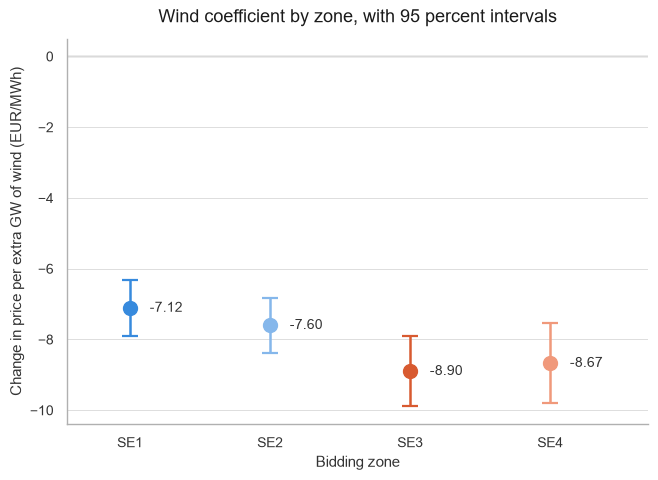

saved C:\Users\ewuzi\Downloads\Project\figures\linkedin\08_wind_coef_by_zone.png


,coef,ci_low,ci_high
zone,,,
SE1,-7.116,-7.913,-6.320
SE2,-7.603,-8.388,-6.819
SE3,-8.904,-9.892,-7.916
SE4,-8.675,-9.805,-7.544


In [10]:
# The wind coefficient with its 95 percent interval, zone by zone.
wind_rows = pd.DataFrame({
    'zone': ZONES,
    'coef': [a2[z].params['wind_onshore_gw'] for z in ZONES],
    'ci_low': [a2[z].conf_int().loc['wind_onshore_gw', 0] for z in ZONES],
    'ci_high': [a2[z].conf_int().loc['wind_onshore_gw', 1] for z in ZONES],
}).set_index('zone')


def draw_coef_by_zone(ax, markersize=10, value_size=10):
    """One dot and interval per zone, each carrying its own printed value."""
    for i, zone in enumerate(ZONES):
        r = wind_rows.loc[zone]
        ax.errorbar(i, r['coef'],
                    yerr=[[r['coef'] - r['ci_low']], [r['ci_high'] - r['coef']]],
                    fmt='o', markersize=markersize, capsize=6, capthick=1.6,
                    elinewidth=1.8, color=ZONE_COLOUR[zone])
        ax.annotate(format(r['coef'], '.2f'), (i + 0.14, r['coef']),
                    va='center', fontsize=value_size, color='#333333')
    ax.axhline(0, color='#999999', linewidth=1, zorder=0)
    ax.set_xticks(range(len(ZONES)))
    ax.set_xticklabels(ZONES)
    ax.set_xlim(-0.45, len(ZONES) - 0.3)
    ax.set_xlabel('Bidding zone')
    ax.set_ylabel('Change in price per extra GW of wind (EUR/MWh)')
    tidy_axes(ax)


fig, ax = plt.subplots(figsize=(7.5, 5))
draw_coef_by_zone(ax)
ax.set_title('Wind coefficient by zone, with 95 percent intervals')
save_fig(fig, '08_wind_coef_by_zone')
plt.show()

fig_li = plt.figure(figsize=LI_FIGSIZE, layout='constrained')
ax_li = fig_li.add_subplot()
draw_coef_by_zone(ax_li, markersize=13, value_size=13)
ax_li.set_title('Wind coefficient by zone\nwith 95 percent intervals, 2021 to 2025', fontsize=16)
ax_li.xaxis.label.set_size(13)
ax_li.yaxis.label.set_size(13)
ax_li.tick_params(labelsize=12)
save_linkedin(fig_li, '08_wind_coef_by_zone')
plt.close(fig_li)

wind_rows.round(3)

## A3. Is the zone difference real?

Four separate regressions produce four different numbers, but that alone does not
establish that they differ. The test is a single stacked regression with zone fixed
effects and wind interacted with zone, and an F-test on the interaction terms
jointly. Standard errors are clustered by zone-day, which allows arbitrary
correlation within a zone within a day.

In [11]:
stacked_formula = ('price_eur_mwh ~ wind_onshore_gw * C(zone) + load_gw + solar_gw '
                   '+ temp_c + flow_sum_gw + ' + CONTROLS)
a3 = smf.ols(stacked_formula, data=hourly).fit(
    cov_type='cluster', cov_kwds={'groups': hourly['zone_day']})
print('observations:', f'{int(a3.nobs):,}', '| clusters:', hourly['zone_day'].nunique())

interactions = [t for t in a3.params.index if t.startswith('wind_onshore_gw:C(zone)')]
ftest = a3.f_test(' = 0, '.join(interactions) + ' = 0')
print()
print('interaction terms:', interactions)
print(f'joint F = {float(ftest.fvalue):.2f}, p = {float(ftest.pvalue):.3e}, df = {ftest.df_num}')

observations: 171,478 | clusters: 7272

interaction terms: ['wind_onshore_gw:C(zone)[T.SE2]', 'wind_onshore_gw:C(zone)[T.SE3]', 'wind_onshore_gw:C(zone)[T.SE4]']
joint F = 9.60, p = 2.536e-06, df = 3.0


In [12]:
a3_tidy = tidy(a3, keep=['wind_onshore_gw'] + interactions + ['load_gw', 'solar_gw', 'temp_c', 'flow_sum_gw'],
               label='stacked, zone FE, clustered by zone-day')
a3_tidy.loc['JOINT F on interactions'] = [round(float(ftest.fvalue), 3), np.nan, np.nan,
                                          float(ftest.pvalue), np.nan, np.nan, 'F-test']
a3_tidy.index.name = 'term'
save_table(a3_tidy, 'a3_zone_interaction')
a3_tidy

saved C:\Users\ewuzi\Downloads\Project\tables\a3_zone_interaction.csv


,coef,se,t,p,ci_low,ci_high,model
term,,,,,,,
wind_onshore_gw,-6.9367,0.3480,-19.9312,0.000000,-7.6188,-6.2546,"stacked, zone FE, clustered by zone-day"
wind_onshore_gw:C(zone)[T.SE2],-0.2599,0.4468,-0.5816,0.560800,-1.1355,0.6158,"stacked, zone FE, clustered by zone-day"
wind_onshore_gw:C(zone)[T.SE3],-1.9023,0.5143,-3.6991,0.000200,-2.9102,-0.8944,"stacked, zone FE, clustered by zone-day"
wind_onshore_gw:C(zone)[T.SE4],-2.4053,0.5592,-4.3017,0.000000,-3.5013,-1.3094,"stacked, zone FE, clustered by zone-day"
load_gw,9.2141,0.3932,23.4324,0.000000,8.4434,9.9847,"stacked, zone FE, clustered by zone-day"
solar_gw,-20.3928,0.8918,-22.8661,0.000000,-22.1407,-18.6448,"stacked, zone FE, clustered by zone-day"
temp_c,-0.5471,0.1122,-4.8772,0.000000,-0.7670,-0.3273,"stacked, zone FE, clustered by zone-day"
flow_sum_gw,1.5984,0.4651,3.4364,0.000600,0.6867,2.5100,"stacked, zone FE, clustered by zone-day"
JOINT F on interactions,9.5990,NaN,NaN,0.000003,NaN,NaN,F-test


## A4. Residual load specification

Energy-Charts defines residual load as **load minus wind minus solar**. Wind is
therefore already inside residual load, and putting both on the right-hand side
would be entering the same variation twice with opposite signs. This specification
replaces wind, load and solar with residual load alone; it is a different question,
not a better version of A2.

In [13]:
a4 = {z: fit_zone(f'price_eur_mwh ~ residual_load_gw + temp_c + flow_sum_gw + {CONTROLS}', z)
      for z in ZONES}
a4_table = summary_col(
    [a4[z] for z in ZONES], model_names=ZONES, stars=True, float_format='%0.3f',
    regressor_order=['residual_load_gw', 'temp_c', 'flow_sum_gw'], drop_omitted=True,
    info_dict={'N': lambda r: f'{int(r.nobs):,}', 'R2': lambda r: f'{r.rsquared:.3f}'},
)
a4_table.add_title('A4. Residual-load specification by zone, Newey-West (24 lags)')
print(a4_table)
a4_tidy = pd.concat([tidy(a4[z], keep=['residual_load_gw', 'temp_c', 'flow_sum_gw'], label=z) for z in ZONES])
a4_tidy.index.name = 'term'
save_table(a4_tidy, 'a4_residual_load')

A4. Residual-load specification by zone, Newey-West (24 lags)
                   SE1      SE2       SE3       SE4   
------------------------------------------------------
residual_load_gw 6.554*** 6.926*** 9.925***  10.231***
                 (0.340)  (0.331)  (0.487)   (0.558)  
temp_c           -0.261   -0.356** -1.552*** -1.438***
                 (0.177)  (0.170)  (0.260)   (0.356)  
flow_sum_gw      2.194*** 1.512*   1.268     0.733    
                 (0.780)  (0.784)  (0.937)   (1.061)  
R-squared        0.399    0.399    0.474     0.416    
R-squared Adj.   0.398    0.399    0.474     0.416    
N                42,743   42,730   42,949    43,056   
R2               0.399    0.399    0.474     0.416    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
saved C:\Users\ewuzi\Downloads\Project\tables\a4_residual_load.csv


'C:\\Users\\ewuzi\\Downloads\\Project\\tables\\a4_residual_load.csv'

## A5. Instrumenting load

Load is not exogenous: price feeds back into demand, so the OLS load coefficient is
contaminated. Temperature is the obvious instrument, and the exploration put load
and mean temperature at -0.788, so the first stage will be strong.

**There is a problem with the request as written, and it needs stating.** In A2
temperature is an included control. A variable cannot be both an included regressor
and an excluded instrument: to instrument load with temperature, temperature has to
come out of the second stage. That is what is done below, and it changes the
exclusion restriction into a strong one: temperature may affect price **only**
through load. In a hydro-dominated system that is doubtful. Temperature moves
snowmelt and reservoir inflow, it moves heating-driven district heating and CHP
output, and cold snaps coincide with low wind in the same weather systems. Any of
those routes puts temperature in the price equation directly and breaks the
restriction.

The IV results below are therefore reported as a diagnostic on the direction and
size of the load endogeneity bias, not as the preferred estimates.

In [14]:
from linearmodels.iv import IV2SLS

iv_formula = ('price_eur_mwh ~ 1 + wind_onshore_gw + solar_gw + flow_sum_gw + '
              + CONTROLS + ' + [load_gw ~ temp_c]')
iv_rows, iv_models = [], {}
for zone in ZONES:
    sub = hourly[hourly['zone'] == zone]
    res = IV2SLS.from_formula(iv_formula, data=sub).fit(cov_type='kernel', kernel='bartlett', bandwidth=24)
    iv_models[zone] = res
    first = res.first_stage.diagnostics
    iv_rows.append({
        'zone': zone,
        'iv_load': round(res.params['load_gw'], 3),
        'iv_load_se': round(res.std_errors['load_gw'], 3),
        'iv_wind': round(res.params['wind_onshore_gw'], 3),
        'iv_wind_se': round(res.std_errors['wind_onshore_gw'], 3),
        'first_stage_F': round(float(first['f.stat'].iloc[0]), 1),
        'first_stage_p': float(first['f.pval'].iloc[0]),
    })
iv_summary = pd.DataFrame(iv_rows).set_index('zone')
save_table(iv_summary, 'a5_iv_load')
iv_summary

saved C:\Users\ewuzi\Downloads\Project\tables\a5_iv_load.csv


,iv_load,iv_load_se,iv_wind,iv_wind_se,first_stage_F,first_stage_p
zone,,,,,,
SE1,8.606,1.503,-7.554,0.369,601.8,0.0
SE2,9.624,1.262,-8.055,0.391,606.5,0.0
SE3,18.952,1.561,-9.327,0.508,959.3,0.0
SE4,16.286,1.951,-8.792,0.579,697.8,0.0


In [15]:
# OLS against IV, side by side, for the two coefficients that move.
compare = pd.DataFrame({
    'ols_load': [round(a2[z].params['load_gw'], 3) for z in ZONES],
    'iv_load': iv_summary['iv_load'],
    'ols_wind': [round(a2[z].params['wind_onshore_gw'], 3) for z in ZONES],
    'iv_wind': iv_summary['iv_wind'],
}, index=ZONES)
compare['load_bias_ols_minus_iv'] = (compare['ols_load'] - compare['iv_load']).round(3)
save_table(compare, 'a5_ols_vs_iv')
compare

saved C:\Users\ewuzi\Downloads\Project\tables\a5_ols_vs_iv.csv


,ols_load,iv_load,ols_wind,iv_wind,load_bias_ols_minus_iv
SE1,4.562,8.606,-7.116,-7.554,-4.044
SE2,4.587,9.624,-7.603,-8.055,-5.037
SE3,12.969,18.952,-8.904,-9.327,-5.983
SE4,14.292,16.286,-8.675,-8.792,-1.994


## A6. Specification checks

Four questions, one cell each: does the result survive differencing, does it survive
a lagged dependent variable, did 2022 have a different slope rather than only a
different level, and did the relationship change when negative prices became common
in 2023.

In [16]:
# Only the wind coefficient is carried forward from each check, since that is the
# quantity under test. Keeping every full result in memory is unnecessary.
def wind_row(res, label, zone, term='wind_onshore_gw'):
    ci = res.conf_int()
    return {'spec': label, 'zone': zone, 'coef': round(res.params[term], 3),
            'se': round(res.bse[term], 3), 'p': round(res.pvalues[term], 4),
            'ci_low': round(ci.loc[term, 0], 3), 'ci_high': round(ci.loc[term, 1], 3),
            'n': int(res.nobs), 'r2': round(res.rsquared, 3)}

checks = [wind_row(a2[z], 'A2 baseline, levels', z) for z in ZONES]
print('baseline captured for', len(checks), 'zones')

baseline captured for 4 zones


In [17]:
# A6a. First differences. The level series are persistent, so the same regression in
# differences is the natural check on whether the level result is spurious.
DIFF_COLS = ['price_eur_mwh', 'wind_onshore_gw', 'load_gw', 'solar_gw', 'temp_c', 'flow_sum_gw']
SLIM = ['zone', 'ts_utc', 'hour', 'month', 'year'] + DIFF_COLS
diff_frames = []
for zone in ZONES:
    sub = hourly.loc[hourly['zone'] == zone, SLIM].sort_values('ts_utc').copy()
    for col in DIFF_COLS:
        sub['d_' + col] = sub[col].diff()
    diff_frames.append(sub.dropna(subset=['d_price_eur_mwh']))
diffs = pd.concat(diff_frames, ignore_index=True)

d_formula = ('d_price_eur_mwh ~ d_wind_onshore_gw + d_load_gw + d_solar_gw + d_temp_c '
             '+ d_flow_sum_gw + ' + CONTROLS)
for zone in ZONES:
    res = smf.ols(d_formula, data=diffs[diffs['zone'] == zone]).fit(**HAC)
    checks.append(wind_row(res, 'A6a first differences', zone, 'd_wind_onshore_gw'))
    del res
print('first differences done')

first differences done


In [18]:
# A6b. Lagged dependent variable. One lag as asked, and a second version with lags 1
# and 24 together, since the ACF put a clear daily echo at lag 24.
lag_frames = []
for zone in ZONES:
    sub = hourly.loc[hourly['zone'] == zone, SLIM].sort_values('ts_utc').copy()
    sub['price_lag1'] = sub['price_eur_mwh'].shift(1)
    sub['price_lag24'] = sub['price_eur_mwh'].shift(24)
    lag_frames.append(sub)
lagged = pd.concat(lag_frames, ignore_index=True)
del diff_frames, lag_frames

for zone in ZONES:
    sub = lagged[lagged['zone'] == zone].dropna(subset=['price_lag1'])
    res = smf.ols(f'price_eur_mwh ~ price_lag1 + {BASE_RHS} + {CONTROLS}', data=sub).fit(**HAC)
    checks.append(wind_row(res, 'A6b lag 1', zone))
    sub24 = lagged[lagged['zone'] == zone].dropna(subset=['price_lag1', 'price_lag24'])
    res24 = smf.ols(f'price_eur_mwh ~ price_lag1 + price_lag24 + {BASE_RHS} + {CONTROLS}',
                    data=sub24).fit(**HAC)
    checks.append(wind_row(res24, 'A6b lags 1 and 24', zone))
    del res, res24
print('lagged dependent variable done')

lagged dependent variable done


In [19]:
# A6c. Did 2022 have a different slope, not just a different level? The 2022 dummy
# itself is absorbed by the year dummies, so only the interaction is identified.
crisis_rows = []
for zone in ZONES:
    res = fit_zone(f'price_eur_mwh ~ wind_onshore_gw * is_2022 + load_gw + solar_gw '
                   f'+ temp_c + flow_sum_gw + {CONTROLS}', zone)
    crisis_rows.append({
        'zone': zone,
        'wind_other_years': round(res.params['wind_onshore_gw'], 3),
        'wind_x_2022': round(res.params['wind_onshore_gw:is_2022'], 3),
        'interaction_p': round(res.pvalues['wind_onshore_gw:is_2022'], 5),
        'wind_in_2022': round(res.params['wind_onshore_gw'] + res.params['wind_onshore_gw:is_2022'], 3),
    })
    del res
crisis = pd.DataFrame(crisis_rows).set_index('zone')
save_table(crisis, 'a6c_wind_x_2022')
crisis

saved C:\Users\ewuzi\Downloads\Project\tables\a6c_wind_x_2022.csv


,wind_other_years,wind_x_2022,interaction_p,wind_in_2022
zone,,,,
SE1,-5.626,-8.234,0.0,-13.860
SE2,-5.882,-9.424,0.0,-15.305
SE3,-5.454,-19.023,0.0,-24.477
SE4,-5.047,-20.058,0.0,-25.105


In [20]:
# A6d. Before and after the negative-price regime change.
for zone in ZONES:
    for label, mask in [('A6d 2021-2022', hourly['year'] <= 2022), ('A6d 2023-2025', hourly['year'] >= 2023)]:
        sub = hourly[(hourly['zone'] == zone) & mask]
        res = smf.ols(f'price_eur_mwh ~ {BASE_RHS} + {CONTROLS}', data=sub).fit(**HAC)
        checks.append(wind_row(res, label, zone))
        del res
print('sample split done')

sample split done


In [21]:
# A7. Drop 2022 entirely.
no2022 = hourly[hourly['year'] != 2022]
for zone in ZONES:
    res = smf.ols(f'price_eur_mwh ~ {BASE_RHS} + {CONTROLS}',
                  data=no2022[no2022['zone'] == zone]).fit(**HAC)
    checks.append(wind_row(res, 'A7 excluding 2022', zone))
    del res

spec_table = pd.DataFrame(checks)
save_table(spec_table.set_index(['spec', 'zone']), 'a6_a7_wind_across_specifications')
spec_pivot = spec_table.pivot(index='spec', columns='zone', values='coef')
print('wind coefficient, EUR/MWh per GW, across specifications')
spec_pivot

saved C:\Users\ewuzi\Downloads\Project\tables\a6_a7_wind_across_specifications.csv
wind coefficient, EUR/MWh per GW, across specifications


zone,SE1,SE2,SE3,SE4
spec,,,,
"A2 baseline, levels",-7.116,-7.603,-8.904,-8.675
A6a first differences,-6.126,-6.269,-6.424,-6.719
A6b lag 1,-0.331,-0.360,-0.662,-0.692
A6b lags 1 and 24,-0.397,-0.413,-0.777,-0.761
A6d 2021-2022,-9.023,-9.902,-14.424,-14.256
A6d 2023-2025,-6.481,-6.710,-6.426,-6.196
A7 excluding 2022,-5.904,-6.181,-6.031,-5.890


saved C:\Users\ewuzi\Downloads\Project\figures\08_wind_coef_across_specs.png


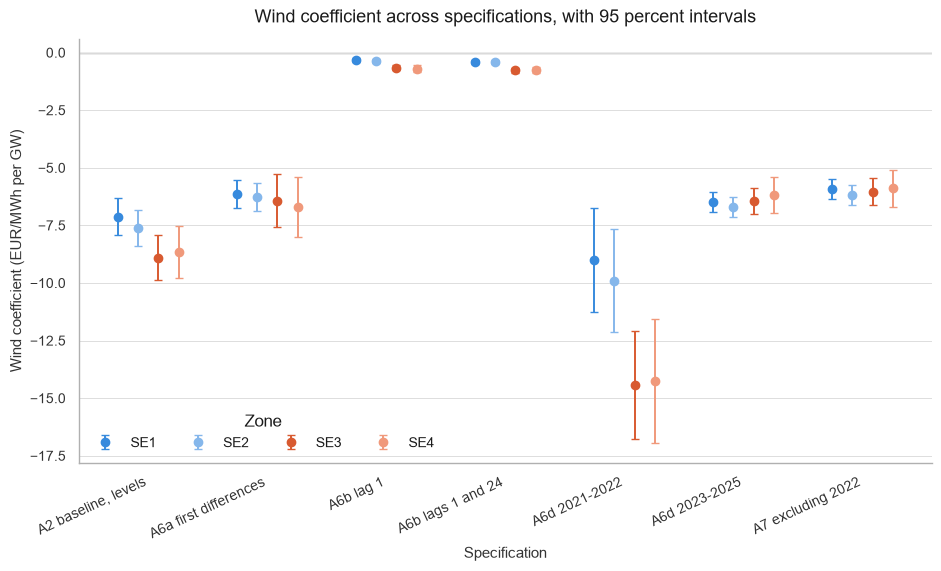

saved C:\Users\ewuzi\Downloads\Project\figures\linkedin\08_wind_coef_across_specs.png


In [22]:
order = spec_pivot.index.tolist()
# A small fixed dodge per zone, always SE1 to SE4 in the same direction, so the
# four estimates in each cluster are separated by position as well as by colour.
OFFSET = {z: (i - 1.5) * 0.17 for i, z in enumerate(ZONES)}


def draw_specs(ax, horizontal=False, markersize=6, capsize=3):
    for zone in ZONES:
        sub = spec_table[spec_table['zone'] == zone].set_index('spec').loc[order]
        pos = [i + OFFSET[zone] for i in range(len(order))]
        lo = sub['coef'] - sub['ci_low']
        hi = sub['ci_high'] - sub['coef']
        if horizontal:
            ax.errorbar(sub['coef'], pos, xerr=[lo, hi], fmt='o', markersize=markersize,
                        capsize=capsize, elinewidth=1.4, label=zone, color=ZONE_COLOUR[zone])
        else:
            ax.errorbar(pos, sub['coef'], yerr=[lo, hi], fmt='o', markersize=markersize,
                        capsize=capsize, elinewidth=1.4, label=zone, color=ZONE_COLOUR[zone])
    if horizontal:
        ax.axvline(0, color='#999999', linewidth=1, zorder=0)
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels(order)
        ax.invert_yaxis()
        ax.set_xlabel('Wind coefficient (EUR/MWh per GW)')
        tidy_axes(ax, grid='x')
    else:
        ax.axhline(0, color='#999999', linewidth=1, zorder=0)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=25, ha='right')
        ax.set_xlabel('Specification')
        ax.set_ylabel('Wind coefficient (EUR/MWh per GW)')
        tidy_axes(ax, grid='y')


fig, ax = plt.subplots(figsize=(11, 5.5))
draw_specs(ax)
ax.set_title('Wind coefficient across specifications, with 95 percent intervals')
ax.legend(title='Zone', ncol=4, frameon=False, loc='lower left')
save_fig(fig, '08_wind_coef_across_specs')
plt.show()

# Portrait reads better with the specifications running down the side.
fig_li = plt.figure(figsize=LI_FIGSIZE, layout='constrained')
ax_li = fig_li.add_subplot()
draw_specs(ax_li, horizontal=True, markersize=8, capsize=3)
ax_li.set_title('Wind coefficient across specifications\nwith 95 percent intervals', fontsize=16)
ax_li.xaxis.label.set_size(13)
ax_li.tick_params(labelsize=12)
ax_li.legend(title='Zone', ncol=4, frameon=False, loc='upper center',
             bbox_to_anchor=(0.5, -0.09), fontsize=12)
save_linkedin(fig_li, '08_wind_coef_across_specs')
plt.close(fig_li)

# Part B. Monthly regional panel

## B1. Shares

Production shares rather than levels, because the zones differ by an order of
magnitude in size and a level comparison would mostly measure how big each zone is.
Net position is also expressed as a share of production, so it reads as the fraction
of output the zone exports.

In [23]:
monthly = monthly.copy()
monthly['date'] = pd.to_datetime(dict(year=monthly['year'], month=monthly['month'], day=1))
monthly['wind_share'] = 100 * monthly['wind_power_gwh'] / monthly['total_production_gwh']
monthly['hydro_share'] = 100 * monthly['hydro_power_including_pump_power_net_gwh'] / monthly['total_production_gwh']
monthly['nuclear_share'] = 100 * monthly['nuclear_power_condensing_net_gwh'] / monthly['total_production_gwh']
monthly['net_position_share'] = 100 * monthly['net_position_gwh'] / monthly['total_production_gwh']
monthly['total_usage_twh'] = monthly['total_usage_gwh'] / 1000.0

shares = ['wind_share', 'hydro_share', 'nuclear_share', 'net_position_share']
print(monthly.groupby('zone')[shares + ['price_eur_mwh', 'temp_c']].mean().round(2).to_string())
save_table(monthly.groupby('zone')[shares + ['price_eur_mwh', 'temp_c']].mean().round(3), 'b1_zone_means')

      wind_share  hydro_share  nuclear_share  net_position_share  price_eur_mwh  temp_c
zone                                                                                   
SE1        22.34        73.91           0.00               55.25          36.81    3.40
SE2        26.44        68.43           0.00               68.28          37.32    4.05
SE3        12.10        13.62          62.56               -9.38          65.98    6.64
SE4        50.37        11.86           0.00             -138.65          81.66    9.50
saved C:\Users\ewuzi\Downloads\Project\tables\b1_zone_means.csv


'C:\\Users\\ewuzi\\Downloads\\Project\\tables\\b1_zone_means.csv'

In [24]:
from linearmodels.panel import PanelOLS, PooledOLS

panel = monthly.set_index(['zone', 'date']).sort_index()
panel['month_of_year'] = panel.index.get_level_values('date').month
panel['cal_year'] = panel.index.get_level_values('date').year

EXOG = ['wind_share', 'net_position_share', 'total_usage_twh', 'temp_c']
X_plain = sm.add_constant(panel[EXOG])
X_fe = pd.concat([panel[EXOG],
                  pd.get_dummies(panel['month_of_year'], prefix='m', drop_first=True).astype(float),
                  pd.get_dummies(panel['cal_year'], prefix='y', drop_first=True).astype(float)], axis=1)
print('panel shape:', panel.shape, '| entities:', panel.index.get_level_values('zone').nunique())

panel shape: (240, 43) | entities: 4


In [25]:
b2_pooled = PooledOLS(panel['price_eur_mwh'], X_plain).fit(cov_type='clustered', cluster_entity=True)
b2_fe = PanelOLS(panel['price_eur_mwh'], X_fe, entity_effects=True).fit(
    cov_type='clustered', cluster_entity=True)

b2 = pd.DataFrame({
    'pooled_coef': b2_pooled.params.reindex(EXOG).round(3),
    'pooled_se': b2_pooled.std_errors.reindex(EXOG).round(3),
    'pooled_p': b2_pooled.pvalues.reindex(EXOG).round(4),
    'fe_coef': b2_fe.params.reindex(EXOG).round(3),
    'fe_se': b2_fe.std_errors.reindex(EXOG).round(3),
    'fe_p': b2_fe.pvalues.reindex(EXOG).round(4),
})
print('pooled R2:', round(b2_pooled.rsquared, 3), '| FE within R2:', round(b2_fe.rsquared_within, 3))
save_table(b2, 'b2_monthly_panel')
b2

pooled R2: 0.287 | FE within R2: 0.553
saved C:\Users\ewuzi\Downloads\Project\tables\b2_monthly_panel.csv


,pooled_coef,pooled_se,pooled_p,fe_coef,fe_se,fe_p
wind_share,-1.043,0.208,0.0000,-1.187,0.188,0.0000
net_position_share,-0.389,0.036,0.0000,-0.189,0.054,0.0006
total_usage_twh,-1.163,0.822,0.1588,3.474,1.242,0.0056
temp_c,-1.251,0.204,0.0000,-2.393,0.587,0.0001


The two columns are doing different things. Pooled OLS compares across zones as well
as over time, so its coefficients carry the cross-sectional difference in price
levels. The fixed-effects column throws that away and identifies only from movement
within a zone over time. If a coefficient changes sign or collapses between the two,
what it was picking up in the pooled column was the permanent difference between
zones, not a response to the variable.

Standard errors are clustered by zone as asked, which means **four clusters**.
Cluster-robust inference is asymptotic in the number of clusters and four is far
below any usable threshold, so the p-values in this table should be read as
suggestive at best. This is noted again in B4.

## B3. Explaining the SE4 minus SE1 gap directly

Rather than inferring the gap from zone fixed effects, difference the two zones and
model the spread itself. Sixty monthly observations, so the specification stays at
three regressors and no fixed effects; anything richer would be fitting noise.

In [26]:
wide = monthly.pivot(index='date', columns='zone')
spread = pd.DataFrame({
    'spread_price': wide['price_eur_mwh']['SE4'] - wide['price_eur_mwh']['SE1'],
    'd_wind_share': wide['wind_share']['SE4'] - wide['wind_share']['SE1'],
    'd_net_position_share': wide['net_position_share']['SE4'] - wide['net_position_share']['SE1'],
    'd_temp_c': wide['temp_c']['SE4'] - wide['temp_c']['SE1'],
}).dropna()
print('observations:', len(spread))
print(spread.describe().round(2).to_string())

observations: 60


       spread_price  d_wind_share  d_net_position_share  d_temp_c
count         60.00         60.00                 60.00     60.00
mean          44.85         28.03               -193.90      6.09
std           42.66          8.91                 47.75      3.62
min            3.84          9.11               -321.57     -1.13
25%           19.68         22.31               -214.33      3.52
50%           34.43         28.57               -187.83      6.29
75%           52.55         33.40               -162.79      8.99
max          272.68         48.96               -103.85     13.12


In [27]:
b3 = smf.ols('spread_price ~ d_wind_share + d_net_position_share + d_temp_c',
             data=spread).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
print(b3.summary())
b3_tidy = tidy(b3, keep=['Intercept', 'd_wind_share', 'd_net_position_share', 'd_temp_c'],
               label='SE4 minus SE1 spread')
b3_tidy.index.name = 'term'
save_table(b3_tidy, 'b3_spread_regression')

                            OLS Regression Results                            
Dep. Variable:           spread_price   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     2.077
Date:                Mon, 21 Sep 2026   Prob (F-statistic):              0.114
Time:                        17:01:53   Log-Likelihood:                -306.34
No. Observations:                  60   AIC:                             620.7
Df Residuals:                      56   BIC:                             629.1
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               39.9741 

'C:\\Users\\ewuzi\\Downloads\\Project\\tables\\b3_spread_regression.csv'

saved C:\Users\ewuzi\Downloads\Project\figures\08_spread_and_net_position.png


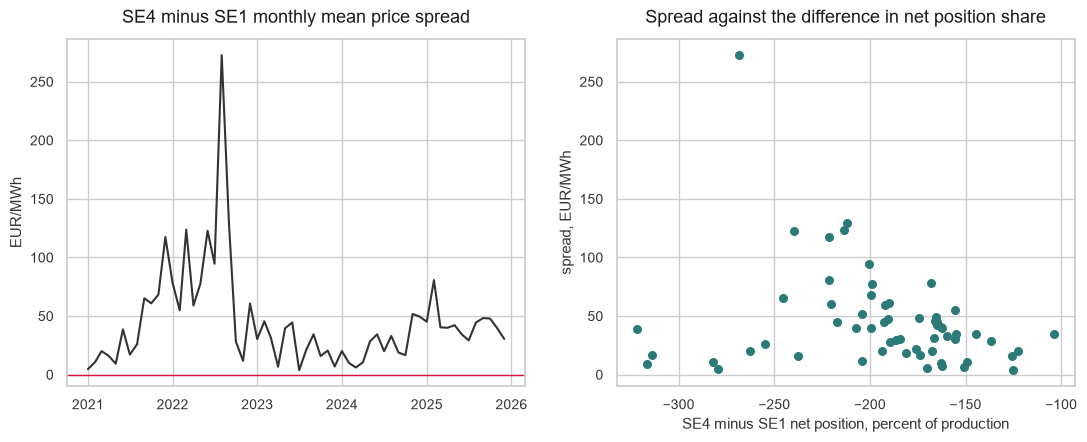

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(spread.index, spread['spread_price'], color='#333333')
axes[0].axhline(0, color='crimson', linewidth=1)
axes[0].set_title('SE4 minus SE1 monthly mean price spread')
axes[0].set_ylabel('EUR/MWh')
axes[1].scatter(spread['d_net_position_share'], spread['spread_price'], s=30, color='#2b7a78')
axes[1].set_title('Spread against the difference in net position share')
axes[1].set_xlabel('SE4 minus SE1 net position, percent of production')
axes[1].set_ylabel('spread, EUR/MWh')
save_fig(fig, '08_spread_and_net_position')
plt.show()

## B4. What the monthly panel can and cannot support

240 observations, four zones, sixty months. The cross-sectional dimension is four,
which is the binding constraint on everything in Part B.

- **Zone fixed effects absorb most of what is interesting.** The SE1 to SE4 price
  difference is close to permanent over this window, so a zone dummy explains it
  almost perfectly and leaves the covariates identified only from within-zone
  movement. That is why B2 is reported both ways.
- **Anything zone-invariant is unidentified once zone effects are in.** Structural
  differences that barely move over five years, transmission capacity between zones
  for instance, cannot be separated from the fixed effect.
- **Clustering on four groups is not real inference.** Reported for completeness,
  but the asymptotics do not apply. Wild cluster bootstrap would be the honest fix
  and even that struggles below about ten clusters.
- **B3 has sixty observations and monthly serial correlation.** HAC at six lags is a
  patch, not a solution.

The monthly panel is for description and for cross-checking the hourly result, not
for a causal claim on its own.

# Part C. Results summary

## Question 1. What does national wind do to the day-ahead price, and does the effect differ across zones?

**It lowers the price everywhere, and by more in the south.** The baseline in A2 puts
an extra gigawatt of national onshore wind at -7.12 EUR/MWh in SE1, -7.60 in SE2,
-8.90 in SE3 and -8.67 in SE4, each estimated on roughly 42,800 hours with
Newey-West standard errors at 24 lags and hour, month and year dummies. Every one is
significant past any threshold worth naming, and the R-squared runs from 0.40 to 0.48.

Note what the wind variable is. Energy-Charts serves Swedish generation nationally,
not per bidding zone, so the same national wind figure is matched against four
different prices. These coefficients are each zone's price response to the national
fleet, not to turbines standing inside that zone.

**The zone differences are real, and they split north against south.** The stacked
regression in A3, with zone fixed effects and standard errors clustered on 7,272
zone-days, gives a joint F of 9.60 on the three interaction terms, p = 0.0000025.
SE2 is statistically indistinguishable from SE1 at -0.26 with p = 0.56. SE3 is 1.90
more negative with p = 0.0002, and SE4 is 2.41 more negative with p below 0.001.

**The result survives the checks that matter.** First differences give -6.13 to
-6.72. Dropping 2022 entirely gives -5.89 to -6.18. Restricting to 2023-2025 gives
-6.20 to -6.71. The lagged-dependent-variable specifications collapse to -0.33 to
-0.78, but that is a different quantity: with the previous hour's price on the
right-hand side the R-squared is 0.92 to 0.96 and the coefficient measures only the
within-hour innovation, not the full effect.

**2022 was a different world.** In A6c the wind effect outside 2022 is -5.0 to -5.6,
and the 2022 interaction adds -8.2 in SE1, -9.4 in SE2, -19.0 in SE3 and -20.1 in
SE4, every one with p below 0.001. When the marginal unit is expensive gas,
displacing an hour of it is worth several times more. The headline A2 numbers are an
average over one normal regime and one extreme one.

**The instrumented version points the same way.** Temperature is a very strong
instrument for load, with first-stage F between 602 and 959. OLS understates load's
effect by 2.0 to 6.0 EUR/MWh per GW, and the wind coefficient becomes slightly more
negative at -7.55, -8.06, -9.33 and -8.79. As A5 argues, the exclusion restriction is
doubtful in a hydro system, so this is evidence on the direction of the load bias
rather than a preferred estimate.

## Question 2. What explains the price difference between SE1 and SE4?

**Not renewables.** SE4 has the highest wind share of any zone, 50.4 percent of its
own production, and the highest price, 81.7 EUR/MWh on monthly averages. SE1 is 73.9
percent hydro, exports the equivalent of 55.3 percent of its production, and averages
36.8. SE4 imports the equivalent of 138.6 percent of its own production. The gap is a
question of where demand sits relative to generation, not of which technology each
zone runs.

**Within a zone, more wind and more exporting do go with lower prices.** The
fixed-effects panel in B2 gives -1.19 EUR/MWh per percentage point of wind share and
-0.19 per point of net export share, both significant, with a within R-squared of
0.553 against a pooled R-squared of 0.287.

**But those forces do not explain the gap itself.** B3 regresses the SE4 minus SE1
spread, which averages 44.85 EUR/MWh over the sixty months, on the differences in
wind share, net position and temperature. Only the wind-share difference is
significant, at -1.02 per point, and the regression explains 11 percent of the
variance with a joint F p-value of 0.114. The spread behaves like a level shift that
these covariates do not track.

That is the honest answer: this dataset describes the gap but cannot identify it. The
missing variables are the ones it does not observe. Transmission capacity between the
zones is not in the data. Cross-border flows are national rather than per zone, so
SE4's coupling to Danish, German and Polish prices, which is the standard explanation
for why an import-dependent southern zone tracks continental prices, cannot be
measured here. Adding zone-level interconnector capacity and neighbouring-country
prices is the natural next step.

## What to keep

1. National wind lowers Swedish day-ahead prices by roughly 6 to 9 EUR/MWh per
   gigawatt, depending on specification and period.
2. The effect is about 2 to 2.4 EUR/MWh stronger in SE3 and SE4 than in SE1 and SE2,
   and that difference is statistically solid.
3. It was three to four times larger during the 2022 gas crisis than outside it.
4. More wind does not close the north-south gap. SE4 has the most wind and the
   highest prices.
5. Part B rests on four zones and sixty months. Its standard errors are not to be
   taken literally, and its role here is to cross-check Part A, not to stand alone.
